# Census sign flips vs. model complexity

Companion to `Real-data example/icu_139_complexity_sweep.ipynb`: the same four complexity sweeps, on the
census design behind Tables 8–9 (ACS 2016, 51 states + 26 industries × 3 group comparisons; the 217 log-income
and 183 insurance cells with n > 50 per group and |ΔY| > 0.01). Everything not being swept is at the paper's
setting (Appendix B.1 / `obd_engine.builders` defaults).

| Family | Knob | Paper setting | Held fixed |
|---|---|---|---|
| XGBoost | `max_depth` 1 … 10 | 3 | 250 trees, lr 0.05, subsample 0.9, colsample 0.9, λ = 1, hist |
| XGBoost | `n_estimators` 10 … 10⁴ | 250 | depth 3, same as above |
| Neural net | width at fixed depth 3, `(w, w, w)`, w = 8 … 256; 3 seeds | `(32, 16)` | ReLU, α = 1e-4, Adam, max_iter 2000, standardized inputs |
| Neural net | depth at fixed width 32, `(32,) × d`, d = 1 … 16; 3 seeds | `(32, 16)` | same |

Flips are counted on point estimates (no bootstrap), like the "is_flip" column of `flip_counts.csv`.
At the paper's settings the sweeps reproduce Tables 8–9 (XGBoost: 34 income / 54 insurance cells) — checked below.

The fits are produced by `census/py/05_complexity_sweep.py` (hours; run it in `tmux` from the repo root,
`OBD_N_JOBS=12 python census/py/05_complexity_sweep.py`), cached per setting in `census/complexity_sweep/*_rows.csv`.
This notebook only reads those caches and draws the figures, in the paper's figure style, into `census/out_py/figures/`.
Settings still missing from the cache are simply absent from the plots.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "obd_engine").exists())   # repo root
SWEEP_DIR = ROOT / "census" / "complexity_sweep"
FIG_DIR = ROOT / "census" / "out_py" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

OUTCOMES = {"pincp": "Log income", "hicov": "Health insurance"}
PAPER_XGB_DEPTH, PAPER_XGB_TREES = 3, 250
NN_WIDTH_DEPTH, NN_DEPTH_WIDTH = 3, 32          # (w, w, w) and (32,) * d

# Tables 8-9 reference values (point-estimate "either" flips) from the final pipeline output.
fc = pd.read_csv(ROOT / "census" / "out_py" / "flip_counts.csv")
PAPER = {(r.y_name, r.algo_name): int(r.is_flip) for r in fc[fc.component == "either"].itertuples()}
N_CELLS = {r.y_name: int(r.n_fit) for r in fc[(fc.component == "either") & (fc.algo_name == "gbt")].itertuples()}
print("paper (Tables 8-9) either-component flips:", {k: v for k, v in PAPER.items() if k[1] in ("gbt", "net")})
print("cells per outcome:", N_CELLS)

# --- figure style of the paper (Real-data example/icu_analysis.ipynb): 8 x 6 in, size-20 fonts,
#     frameless legend, faint grid, 2.5-pt lines, PDF at 300 dpi; component colours as in prob_unexplained.pdf.
FS = 20
COL_EITHER, COL_EXPL, COL_UNEXPL, COL_PAPER = "black", "#785EF0", "#FE6100", "0.45"

def paper_axes(ax, xlabel, ylabel, ymax, logx=False, legend_loc="upper right"):
    ax.set_xlabel(xlabel, fontsize=FS); ax.set_ylabel(ylabel, fontsize=FS)
    ax.set_ylim(0, ymax * 1.02)
    if logx: ax.set_xscale("log")
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis="both", which="major", labelsize=FS)
    ax.legend(fontsize=FS - 4, loc=legend_loc, frameon=False)

def save_panel(fig, stem):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{stem}.pdf", format="pdf", bbox_inches="tight", dpi=300)
    fig.savefig(FIG_DIR / f"{stem}.png", format="png", bbox_inches="tight", dpi=150)
    # variant without the y-axis label, for the paper's multi-panel figure (one shared y label)
    ylab = fig.axes[0].get_ylabel(); fig.axes[0].set_ylabel("")
    fig.savefig(FIG_DIR / f"{stem}_noylabel.pdf", format="pdf", bbox_inches="tight", dpi=300)
    fig.axes[0].set_ylabel(ylab)

paper (Tables 8-9) either-component flips: {('hicov', 'gbt'): 54, ('hicov', 'net'): 65, ('pincp', 'gbt'): 34, ('pincp', 'net'): 87}
cells per outcome: {'hicov': 183, 'pincp': 217}


## 1. Load the cached sweeps

In [2]:
def load_rows(sweep):
    p = SWEEP_DIR / f"{sweep}_rows.csv"
    if not p.exists():
        print(f"{p.name}: not found (sweep not run yet)"); return None
    df = pd.read_csv(p, keep_default_na=False)
    for c in ("any_flip", "explained_flip", "unexplained_flip"):
        df[c] = df[c].astype(str).str.lower().eq("true")
    df["error"] = df["error"].astype(str)
    print(f"{p.name}: {len(df):,} rows, {df.setting.nunique()} settings, {int((df.error != '').sum())} errors")
    return df

xgbd = load_rows("xgb_depth"); xgbt = load_rows("xgb_trees")
nnw = load_rows("nn_width"); nnd = load_rows("nn_depth")

def summarize(df, knob):
    return (df.groupby(["y_name", knob])
              .agg(total_flips=("any_flip", "sum"), explained_flips=("explained_flip", "sum"),
                   unexplained_flips=("unexplained_flip", "sum"), n_cells=("any_flip", "size"),
                   n_errors=("error", lambda s: int((s != "").sum())))
              .reset_index())

def summarize_seeds(df, knob):
    per_seed = (df.groupby(["y_name", knob, "seed"])
                  .agg(total=("any_flip", "sum"), explained=("explained_flip", "sum"),
                       unexplained=("unexplained_flip", "sum"), n_errors=("error", lambda s: int((s != "").sum())))
                  .reset_index())
    agg = (per_seed.groupby(["y_name", knob])
                   .agg(total_mean=("total", "mean"), total_min=("total", "min"), total_max=("total", "max"),
                        explained_mean=("explained", "mean"), unexplained_mean=("unexplained", "mean"),
                        n_seeds=("seed", "nunique"), n_errors=("n_errors", "sum"))
                   .reset_index())
    return per_seed, agg

def nn_n_params(hidden, n_in, n_out=1):
    sizes = [n_in, *hidden, n_out]
    return int(sum(a * b + b for a, b in zip(sizes[:-1], sizes[1:])))

xgb_depth_rows.csv: 4,000 rows, 10 settings, 0 errors
xgb_trees_rows.csv: 4,000 rows, 10 settings, 0 errors
nn_width_rows.csv: 7,200 rows, 18 settings, 0 errors
nn_depth_rows.csv: 9,600 rows, 24 settings, 0 errors


## 2. XGBoost: tree depth and number of trees

Depth 3 / 250 trees must reproduce Tables 8–9 (34 income, 54 insurance).

pincp: depth 3 -> 34 flips | Tables 8-9: 34


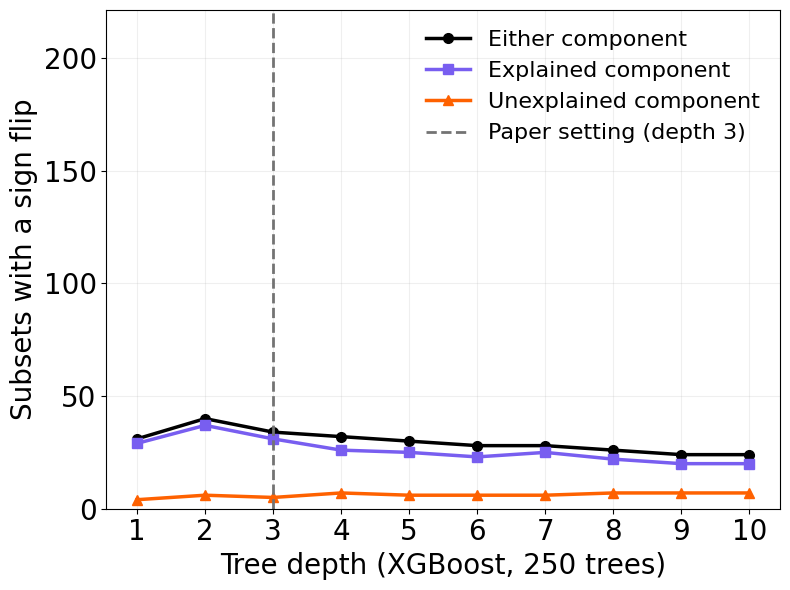

hicov: depth 3 -> 54 flips | Tables 8-9: 54


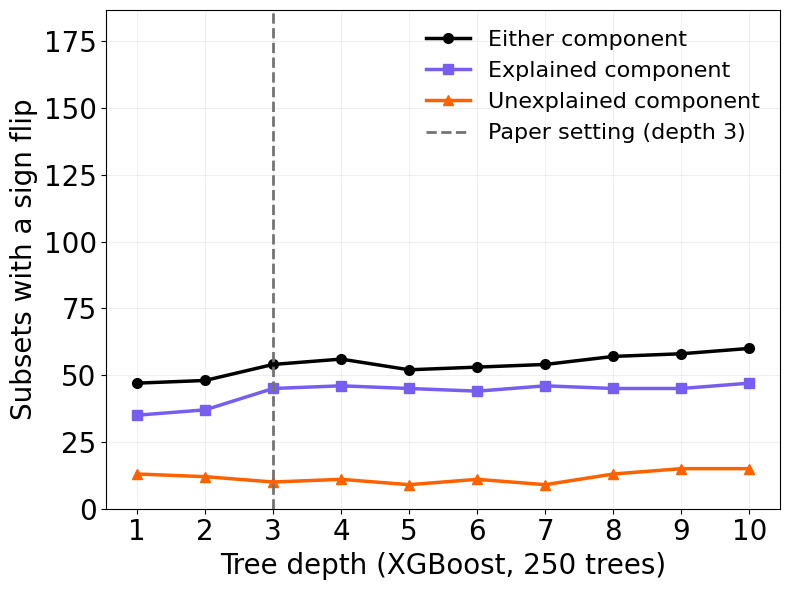

total_flips       explained_flips       unexplained_flips      
y_name          hicov pincp           hicov pincp             hicov pincp
max_depth                                                                
1                  47    31              35    29                13     4
2                  48    40              37    37                12     6
3                  54    34              45    31                10     5
4                  56    32              46    26                11     7
5                  52    30              45    25                 9     6
6                  53    28              44    23                11     6
7                  54    28              46    25                 9     6
8                  57    26              45    22                13     7
9                  58    24              45    20                15     7
10                 60    24              47    20                15     7

pincp: 250 trees -> 34 flips | Tables 8-9: 34


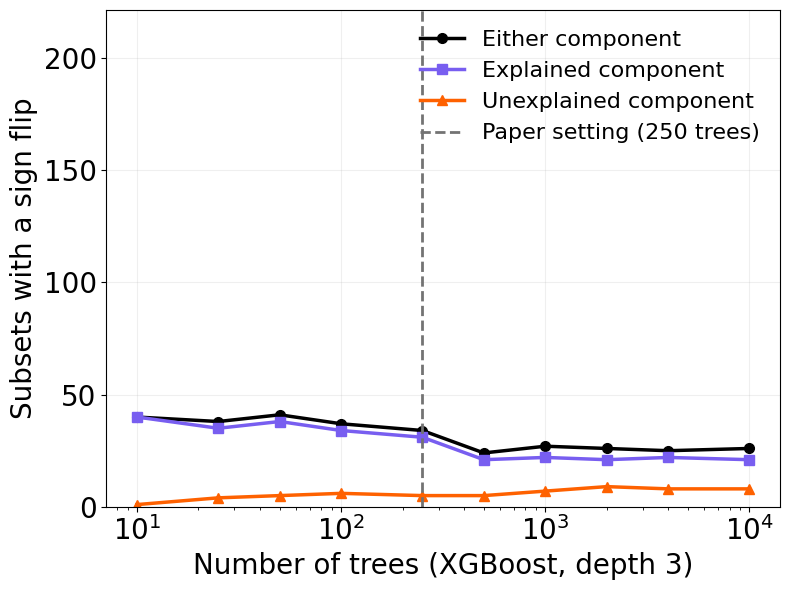

hicov: 250 trees -> 54 flips | Tables 8-9: 54


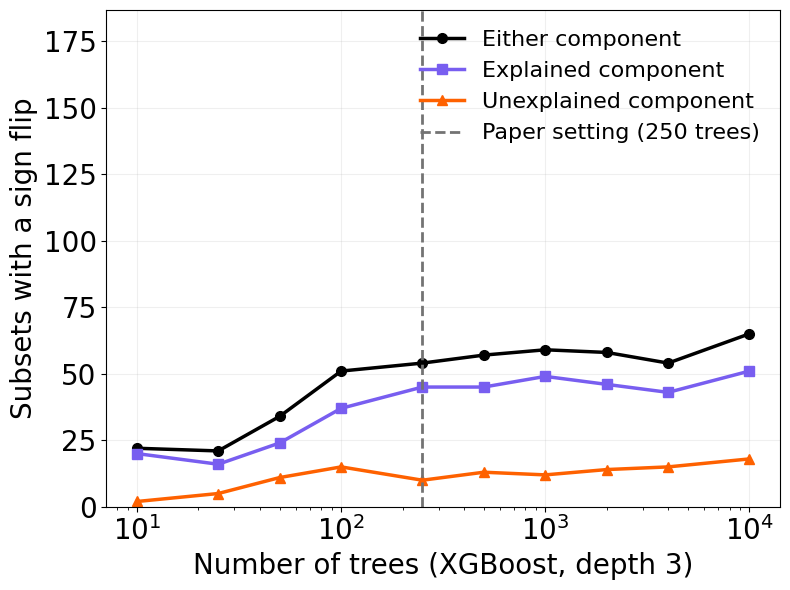

total_flips       explained_flips       unexplained_flips      
y_name             hicov pincp           hicov pincp             hicov pincp
n_estimators                                                                
10                    22    40              20    40                 2     1
25                    21    38              16    35                 5     4
50                    34    41              24    38                11     5
100                   51    37              37    34                15     6
250                   54    34              45    31                10     5
500                   57    24              45    21                13     5
1000                  59    27              49    22                12     7
2000                  58    26              46    21                14     9
4000                  54    25              43    22                15     8
10000                 65    26              51    21                18     8

In [3]:
def flips_panel(summary, y, knob, xlabel, paper_x, paper_label, stem, logx=False, xticks=None):
    s = summary[summary.y_name == y].sort_values(knob)
    fig, ax = plt.subplots(figsize=(8, 6))
    for col, lab, c, m in [("total_flips", "Either component", COL_EITHER, "o"),
                           ("explained_flips", "Explained component", COL_EXPL, "s"),
                           ("unexplained_flips", "Unexplained component", COL_UNEXPL, "^")]:
        ax.plot(s[knob], s[col], color=c, linewidth=2.5, marker=m, markersize=7, label=lab)
    ax.axvline(paper_x, color=COL_PAPER, linestyle="--", linewidth=2, label=paper_label)
    paper_axes(ax, xlabel, "Subsets with a sign flip", N_CELLS[y], logx=logx)
    if xticks is not None: ax.set_xticks(xticks)
    save_panel(fig, f"{stem}_{y}"); plt.show()

if xgbd is not None:
    xgbd["max_depth"] = xgbd["setting"].str.split().str[-1].astype(int)
    xgbd_summary = summarize(xgbd, "max_depth"); xgbd_summary.to_csv(SWEEP_DIR / "xgb_depth_summary.csv", index=False)
    for y in OUTCOMES:
        chk = xgbd_summary[(xgbd_summary.y_name == y) & (xgbd_summary.max_depth == PAPER_XGB_DEPTH)]
        if len(chk): print(f"{y}: depth {PAPER_XGB_DEPTH} -> {int(chk.total_flips.iloc[0])} flips | Tables 8-9: {PAPER[(y, 'gbt')]}")
        flips_panel(xgbd_summary, y, "max_depth", "Tree depth (XGBoost, 250 trees)", PAPER_XGB_DEPTH, "Paper setting (depth 3)",
                    "census_complexity_xgb_depth", xticks=sorted(xgbd_summary.max_depth.unique()))
    display(xgbd_summary.pivot(index="max_depth", columns="y_name", values=["total_flips", "explained_flips", "unexplained_flips"]))

if xgbt is not None:
    xgbt["n_estimators"] = xgbt["setting"].str.split().str[-1].astype(int)
    xgbt_summary = summarize(xgbt, "n_estimators"); xgbt_summary.to_csv(SWEEP_DIR / "xgb_trees_summary.csv", index=False)
    for y in OUTCOMES:
        chk = xgbt_summary[(xgbt_summary.y_name == y) & (xgbt_summary.n_estimators == PAPER_XGB_TREES)]
        if len(chk): print(f"{y}: {PAPER_XGB_TREES} trees -> {int(chk.total_flips.iloc[0])} flips | Tables 8-9: {PAPER[(y, 'gbt')]}")
        flips_panel(xgbt_summary, y, "n_estimators", "Number of trees (XGBoost, depth 3)", PAPER_XGB_TREES, "Paper setting (250 trees)",
                    "census_complexity_xgb_trees", logx=True)
    display(xgbt_summary.pivot(index="n_estimators", columns="y_name", values=["total_flips", "explained_flips", "unexplained_flips"]))

## 3. Neural net: width at depth 3, depth at width 32 (three seeds each)

Solid line: mean over seeds; band: min–max over seeds. Dashed line: the paper's `(32, 16)` net (Tables 8–9: 87 income, 65 insurance). The parameter count uses the cell's own number of input features (state and industry one-hots differ by subset), averaged over cells.

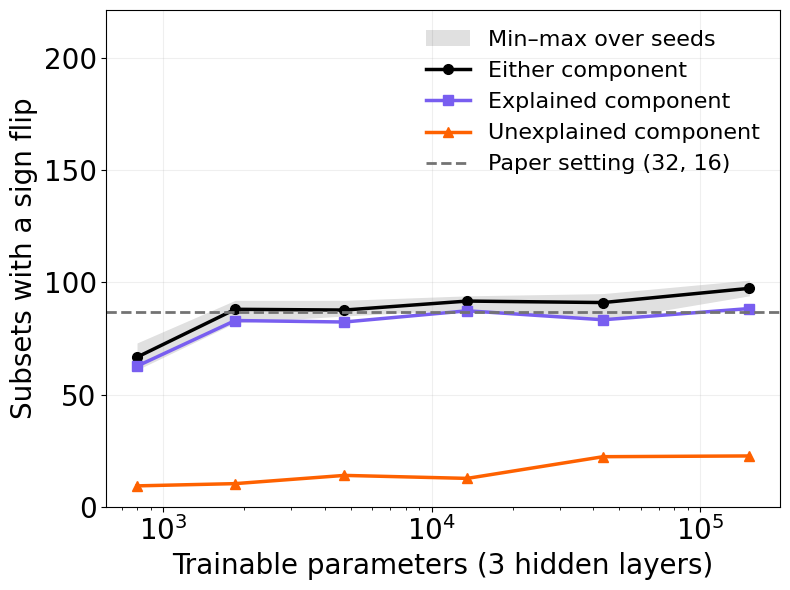

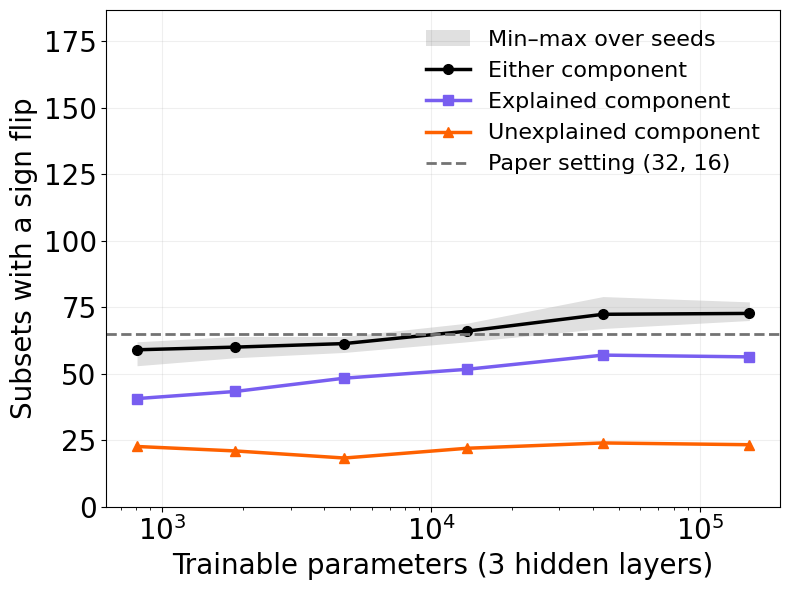

,y_name,width,total_mean,total_min,total_max,explained_mean,unexplained_mean,n_seeds,n_errors,n_params
0,hicov,8,59.000000,53,62,40.666667,22.666667,3,0,804
1,hicov,16,60.000000,56,64,43.333333,21.000000,3,0,1862
2,hicov,32,61.333333,58,64,48.333333,18.333333,3,0,4748
3,hicov,64,66.000000,62,69,51.666667,22.000000,3,0,13591
4,hicov,128,72.333333,67,79,57.000000,24.000000,3,0,43564
5,hicov,256,72.666667,70,77,56.333333,23.333333,3,0,152664
6,pincp,8,66.666667,61,73,62.666667,9.333333,3,0,798
7,pincp,16,88.000000,82,92,83.000000,10.333333,3,0,1852
8,pincp,32,87.666667,85,92,82.333333,14.000000,3,0,4727
9,pincp,64,91.666667,88,94,87.333333,12.666667,3,0,13549


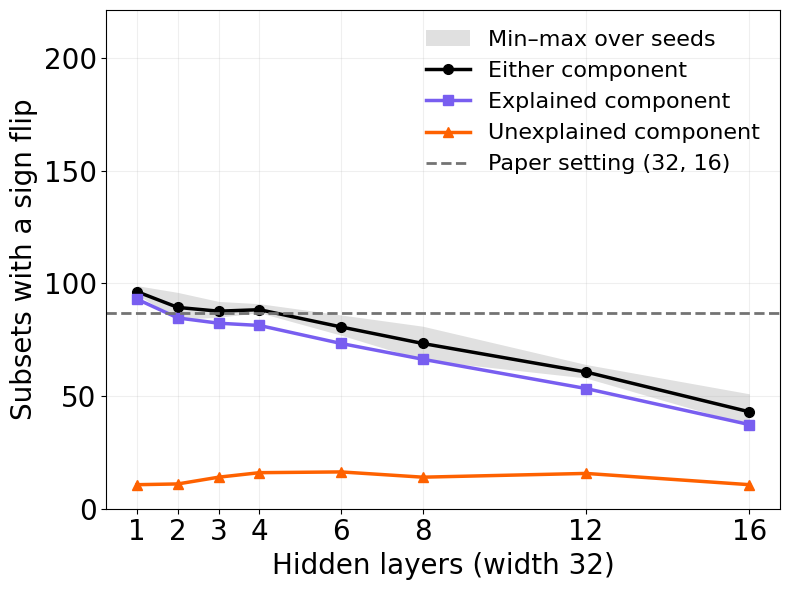

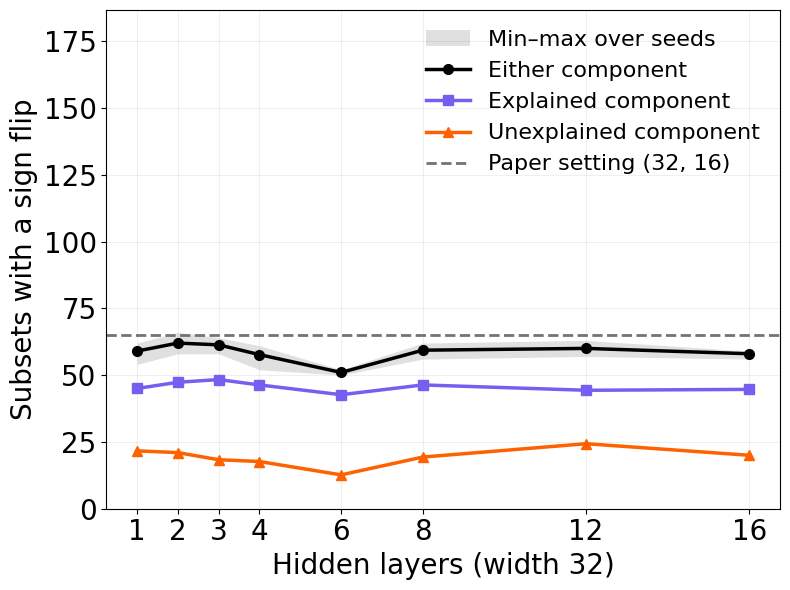

,y_name,depth,total_mean,total_min,total_max,explained_mean,unexplained_mean,n_seeds,n_errors,n_params
0,hicov,1,59.000000,54,62,45.000000,21.666667,3,0,2636
1,hicov,2,62.000000,58,66,47.333333,21.000000,3,0,3692
2,hicov,3,61.333333,58,64,48.333333,18.333333,3,0,4748
3,hicov,4,57.666667,52,61,46.333333,17.666667,3,0,5804
4,hicov,6,51.000000,50,52,42.666667,12.666667,3,0,7916
5,hicov,8,59.333333,56,62,46.333333,19.333333,3,0,10028
6,hicov,12,60.000000,57,63,44.333333,24.333333,3,0,14252
7,hicov,16,58.000000,56,59,44.666667,20.000000,3,0,18476
8,pincp,1,96.333333,95,99,93.000000,10.666667,3,0,2615
9,pincp,2,89.333333,84,96,84.666667,11.000000,3,0,3671


In [4]:
def seed_panel(per_seed, agg, y, knob, xlabel, stem, logx=False, xticks=None):
    a = agg[agg.y_name == y].sort_values(knob)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.fill_between(a[knob], a["total_min"], a["total_max"], color=COL_EITHER, alpha=0.12, linewidth=0, label="Min–max over seeds")
    ax.plot(a[knob], a["total_mean"], color=COL_EITHER, linewidth=2.5, marker="o", markersize=7, label="Either component")
    ax.plot(a[knob], a["explained_mean"], color=COL_EXPL, linewidth=2.5, marker="s", markersize=7, label="Explained component")
    ax.plot(a[knob], a["unexplained_mean"], color=COL_UNEXPL, linewidth=2.5, marker="^", markersize=7, label="Unexplained component")
    ax.axhline(PAPER[(y, "net")], color=COL_PAPER, linestyle="--", linewidth=2, label="Paper setting (32, 16)")
    paper_axes(ax, xlabel, "Subsets with a sign flip", N_CELLS[y], logx=logx)
    if xticks is not None: ax.set_xticks(xticks)
    save_panel(fig, f"{stem}_{y}"); plt.show()

if nnw is not None:
    nnw["width"] = nnw["setting"].str.extract(r"w=(\d+)").astype(int)
    nnw["seed"] = nnw["setting"].str.extract(r"s=(\d+)").astype(int)
    nnw["n_params"] = [nn_n_params((w,) * NN_WIDTH_DEPTH, p) for w, p in zip(nnw["width"], nnw["n_features"])]
    nnw_per_seed, nnw_summary = summarize_seeds(nnw, "width")
    mean_params = nnw.groupby(["y_name", "width"])["n_params"].mean().round().astype(int).rename("n_params").reset_index()
    nnw_summary = nnw_summary.merge(mean_params); nnw_summary.to_csv(SWEEP_DIR / "nn_width_summary.csv", index=False)
    for y in OUTCOMES:
        seed_panel(nnw_per_seed, nnw_summary, y, "n_params", "Trainable parameters (3 hidden layers)", "census_complexity_nn_width", logx=True)
        plt.close("all")
    display(nnw_summary)

if nnd is not None:
    nnd["depth"] = nnd["setting"].str.extract(r"d=(\d+)").astype(int)
    nnd["seed"] = nnd["setting"].str.extract(r"s=(\d+)").astype(int)
    nnd["n_params"] = [nn_n_params((NN_DEPTH_WIDTH,) * d, p) for d, p in zip(nnd["depth"], nnd["n_features"])]
    nnd_per_seed, nnd_summary = summarize_seeds(nnd, "depth")
    mean_params = nnd.groupby(["y_name", "depth"])["n_params"].mean().round().astype(int).rename("n_params").reset_index()
    nnd_summary = nnd_summary.merge(mean_params); nnd_summary.to_csv(SWEEP_DIR / "nn_depth_summary.csv", index=False)
    for y in OUTCOMES:
        seed_panel(nnd_per_seed, nnd_summary, y, "depth", "Hidden layers (width 32)", "census_complexity_nn_depth",
                   xticks=sorted(nnd_summary.depth.unique()))
    display(nnd_summary)

## 4. Summary table and preview montage

total_flips        \
y_name                                                         hicov pincp   
family                             knob                                      
XGBoost depth                      depth 1                      47.0  31.0   
                                   depth 2                      48.0  40.0   
                                   depth 3                      54.0  34.0   
                                   depth 4                      56.0  32.0   
                                   depth 5                      52.0  30.0   
                                   depth 6                      53.0  28.0   
                                   depth 7                      54.0  28.0   
                                   depth 8                      57.0  26.0   
                                   depth 9                      58.0  24.0   
                                   depth 10                     60.0  24.0   
XGBoost trees                      10 trees                     22.0  40.0   
                                   25 trees                     21.0  38.0   
                                   50 trees                     34.0  41.0   
                                   100 trees                    51.0  37.0   
                                   250 trees                    54.0  34.0   
                                   500 trees                    57.0  24.0   
                                   1000 trees                   59.0  27.0   
                                   2000 trees                   58.0  26.0   
                                   4000 trees                   54.0  25.0   
                                   10000 trees                  65.0  26.0   
NN width, depth 3 (mean of seeds)  w=8 (804 params)             59.0   NaN   
                                   w=16 (1862 params)           60.0   NaN   
                                   w=32 (4748 params)           61.3   NaN   
                                   w=64 (13591 params)          66.0   NaN   
                                   w=128 (43564 params)         72.3   NaN   
                                   w=256 (152664 params)        72.7   NaN   
                                   w=8 (798 params)              NaN  66.7   
                                   w=16 (1852 params)            NaN  88.0   
                                   w=32 (4727 params)            NaN  87.7   
                                   w=64 (13549 params)           NaN  91.7   
                                   w=128 (43480 params)          NaN  91.0   
                                   w=256 (152496 params)         NaN  97.3   
NN depth, width 32 (mean of seeds) d=1 (2636 params)            59.0   NaN   
                                   d=2 (3692 params)            62.0   NaN   
                                   d=3 (4748 params)            61.3   NaN   
                                   d=4 (5804 params)            57.7   NaN   
                                   d=6 (7916 params)            51.0   NaN   
                                   d=8 (10028 params)           59.3   NaN   
                                   d=12 (14252 params)          60.0   NaN   
                                   d=16 (18476 params)          58.0   NaN   
                                   d=1 (2615 params)             NaN  96.3   
                                   d=2 (3671 params)             NaN  89.3   
                                   d=3 (4727 params)             NaN  87.7   
                                   d=4 (5783 params)             NaN  88.3   
                                   d=6 (7895 params)             NaN  80.7   
                                   d=8 (10007 params)            NaN  73.3   
                                   d=12 (14231 params)           NaN  60.7   
                                   d=16 (18455 params)           NaN  43.0   

                                                         explained_flips  \
y_

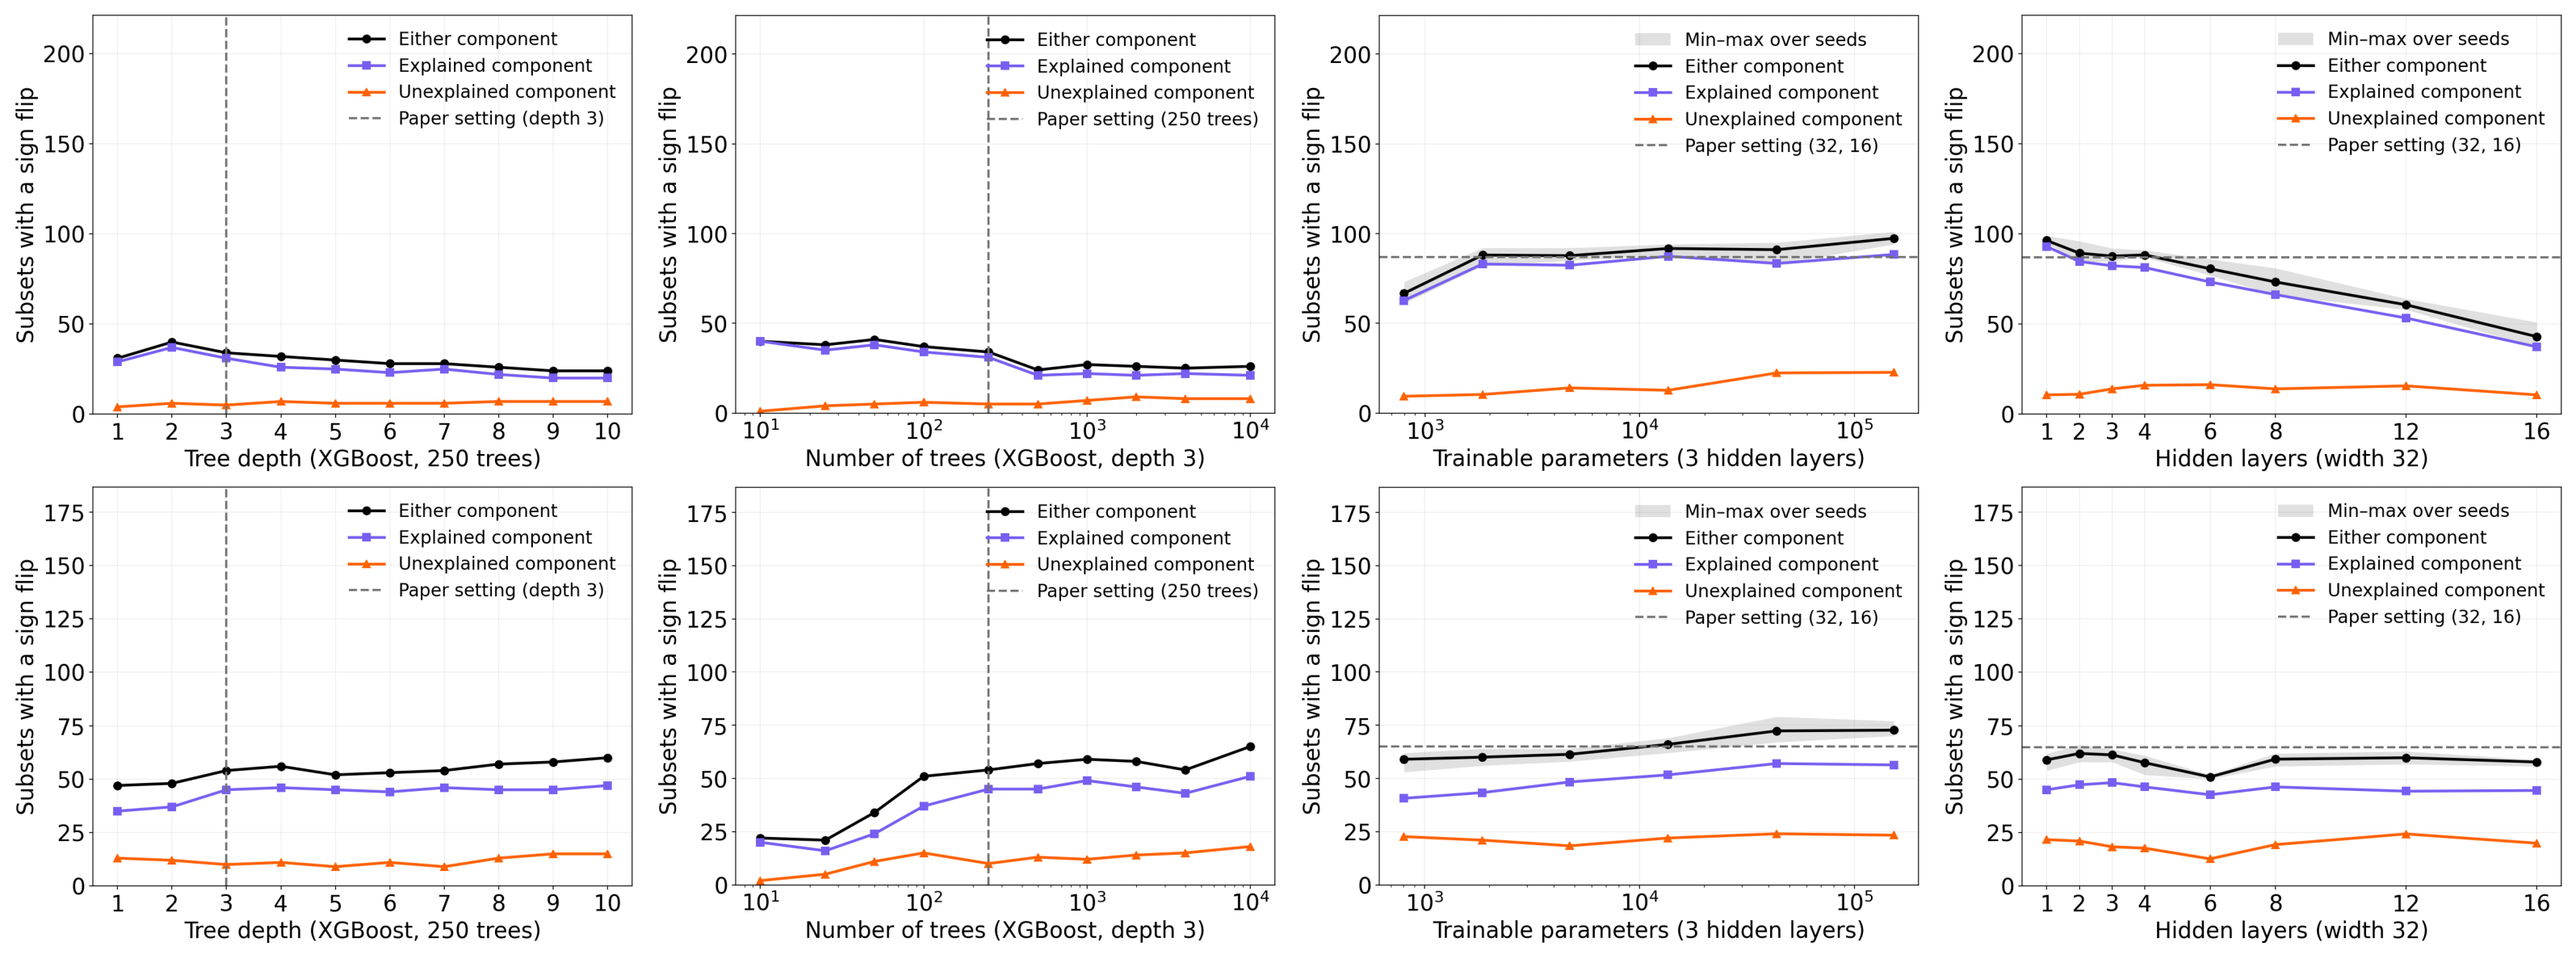

In [5]:
parts = []
if xgbd is not None:
    parts.append(xgbd_summary.assign(family="XGBoost depth", knob=lambda d: "depth " + d.max_depth.astype(str)))
if xgbt is not None:
    parts.append(xgbt_summary.assign(family="XGBoost trees", knob=lambda d: d.n_estimators.astype(str) + " trees"))
if nnw is not None:
    parts.append(nnw_summary.assign(family="NN width, depth 3 (mean of seeds)", knob=lambda d: "w=" + d.width.astype(str) + " (" + d.n_params.astype(str) + " params)",
                                    total_flips=lambda d: d.total_mean.round(1), explained_flips=lambda d: d.explained_mean.round(1), unexplained_flips=lambda d: d.unexplained_mean.round(1)))
if nnd is not None:
    parts.append(nnd_summary.assign(family="NN depth, width 32 (mean of seeds)", knob=lambda d: "d=" + d.depth.astype(str) + " (" + d.n_params.astype(str) + " params)",
                                    total_flips=lambda d: d.total_mean.round(1), explained_flips=lambda d: d.explained_mean.round(1), unexplained_flips=lambda d: d.unexplained_mean.round(1)))
cols = ["family", "knob", "y_name", "total_flips", "explained_flips", "unexplained_flips", "n_errors"]
side = pd.concat([p[cols] for p in parts], ignore_index=True)
side.to_csv(SWEEP_DIR / "census_complexity_summary.csv", index=False)
display(side.pivot_table(index=["family", "knob"], columns="y_name", values=["total_flips", "explained_flips", "unexplained_flips"], sort=False))

import matplotlib.image as mpimg
stems = [s for s in ["census_complexity_xgb_depth", "census_complexity_xgb_trees", "census_complexity_nn_width", "census_complexity_nn_depth"]
         if (FIG_DIR / f"{s}_pincp.png").exists()]
if stems:
    fig, axes = plt.subplots(2, len(stems), figsize=(8 * len(stems), 12), squeeze=False)
    for j, s in enumerate(stems):
        for i, y in enumerate(OUTCOMES):
            axes[i, j].imshow(mpimg.imread(FIG_DIR / f"{s}_{y}.png")); axes[i, j].axis("off")
    fig.tight_layout(); fig.savefig(FIG_DIR / "census_complexity_all.png", dpi=80, bbox_inches="tight"); plt.show()